<a href="https://colab.research.google.com/github/alejolion57-stack/Portafolio_Alejandro-Leon/blob/main/Proyecto_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proyecto NovaRetail+**
-


---
NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios. Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

Para ello, me pidieron un análisis correlacional completo sobre un nuevo dataset en español.

---
**💡Metodología**

1. Integrar correlaciones.
2. Identificar relaciones significativas entre variables mediante el uso de scatterplots y heatmaps.
3. Detectar correlaciones engañosas.
4. Documentar supuestos y limitaciones.
5. Convertir hallazgos en recomendaciones de negocio y transformarlas en un reporte.

**🛠️ Herramientas usadas**
Jupyter Notebook
Python: pandas, numpy, seaborn, matplotlib

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 15000 entries, 0 to 14999
,Data columns (total 12 columns):
, #   Column                     Non-Null Count  Dtype  
,---  ------                     --------------  -----  
, 0   id_cliente                 15000 non-null  object 
, 1   edad                       15000 non-null  float64
, 2   nivel_ingreso              15000 non-null  float64
, 3   visitas_mes                15000 non-null  int64  
, 4   compras_mes                15000 non-null  int64  
, 5   gasto_publicidad_dirigida  15000 non-null  float64
, 6   satisfaccion               15000 non-null  float64
, 7   miembro_premium            15000 non-null  int64  
, 8   abandono                   15000 non-null  int64  
, 9   tipo_dispositivo           15000 non-null  object 
, 10  region                     15000 non-null  object 
, 11  ingreso_anual              15000 non-null  float64
,dtypes: float64(5), int64(4), object(3)
,memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


---
**📊Preparación de datos y documentación de supuestos**
-

---
🔍**Exploración inicial de los datos**
-

1. El conjunto de datos contiene **15,000 registros**
2. **12 columnas**, sin valores nulos.
3. **Se identifican 9 columnas numéricas:**
  - `edad`
  - `nivel_ingreso`              
  - `visitas_mes`                 
  - `compras_mes`                  
  - `gasto_publicidad_dirigida`  
  - `satisfaccion`               
  - `miembro_premium`            
  - `abandono`                    
  - `ingreso_anual`              

   **La mayoría de estas variables presentan tipos de datos adecuados.  
   La columna edad(float64)** debe ser ajustada para que muestre
   valores enteros(int64).

---
🆔**Variables binarias**  
-
   Las siguientes columnas representan variables binarias:
   - `miembro_premium`
   - `abandono`

   **Ambas están codificadas como 0 y 1. No requieren transformación
   adicional**.

---
📊**Variables categóricas**  
-
   Se identifican 3 columnas categóricas:
   - `id_cliente`
   - `tipo_dispositivo`
   - `region`

  👌**Estas variables están correctamente definidas y no requieren
  transformación adicional.**

  ---

In [ ]:
# Corregir el tipo de dato
df.dtypes

id_cliente                    object
edad                         float64
nivel_ingreso                float64
visitas_mes                    int64
compras_mes                    int64
gasto_publicidad_dirigida    float64
satisfaccion                 float64
miembro_premium                int64
abandono                       int64
tipo_dispositivo              object
region                        object
ingreso_anual                float64
dtype: object

---
👁️**Analisis preliminar de la estructura de datos**
-
Primero uso df.types para ver en detalle el tipo de datos que se encuentran en el dataset:

**Descubrimiento:** Edad debe cambiarse de **float64 a int64** para asegurar la calidad de los datos (de un promedio a un entero).


In [ ]:
#Ajuste del tipo de datos
df["edad"] = df["edad"].astype(int)

# verificar cambios
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 15000 entries, 0 to 14999
,Data columns (total 12 columns):
, #   Column                     Non-Null Count  Dtype  
,---  ------                     --------------  -----  
, 0   id_cliente                 15000 non-null  object 
, 1   edad                       15000 non-null  int64  
, 2   nivel_ingreso              15000 non-null  float64
, 3   visitas_mes                15000 non-null  int64  
, 4   compras_mes                15000 non-null  int64  
, 5   gasto_publicidad_dirigida  15000 non-null  float64
, 6   satisfaccion               15000 non-null  float64
, 7   miembro_premium            15000 non-null  int64  
, 8   abandono                   15000 non-null  int64  
, 9   tipo_dispositivo           15000 non-null  object 
, 10  region                     15000 non-null  object 
, 11  ingreso_anual              15000 non-null  float64
,dtypes: float64(4), int64(5), object(3)
,memory usage: 1.4+ MB


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


---
**#️⃣ Exploración de variables numéricas**
-
---

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000



---
📝**Diagnóstico inicial de** ***variables numéricas***
-
**Columna:`edad`**
- La edad promedio es **38 años**.
- La mayoría de usuarios está entre **30 y 46 años**, indicando una base
  relativamente madura y estable.

**Columna:`nivel_ingreso`**
- El ingreso promedio ronda los **30 mil**.
- **Hay bastante dispersión (std ≈ 9.8k)**, lo que indica una mezcla
  importante entre clientes de ingresos bajos y altos.

**Columna:`visitas_mes`**

  Los usuarios visitan en promedio **10 veces al mes**.El comportamiento
  parece frecuente y consistente.

**Columna:`compras_mes`**

  Aunque hay muchas visitas, las compras promedio son solo **1.2 al
  mes**. Esto sugiere una oportunidad clara para mejorar conversión.

**Columna:`gasto_publicidad_dirigida`**
- El gasto promedio en publicidad dirigida es de **20.15** vemos que
  mientras algunos clientes no reciben inversión publicitaria (**min
  0**), otros alcanzan niveles muy altos (**max =75.51**).
- El hecho de que el **75% de los usuarios reciba menos de 27.29**  
  Sugiere que la empresa aplica una estrategia de segmentación,
  destinando mayores recursos a ciertos perfiles específicos.

**Columna:`satisfaccion`**
- La satisfacción promedio de los usuarios es de **3.6 sobre 5**, lo que
  indica una percepción generalmente positiva de la experiencia.
- El hecho de que el **75% de los clientes tenga una satisfacción
  superior a 3.1**  muesta evaluaciones del servicio aceptables.
- La cercanía entre la mediana (**3.6**) y el promedio sugiere una d
  distribución relativamente estable, sin extremos que distorsionen
  significativamente los resultados.
-  Sin embargo, el rango completo hasta el valor máximo (**5**) indica
  que sí **existe un grupo de usuarios altamente satisfechos**, lo que
  puede servir como referencia para **identificar buenas prácticas** o
  factores asociados a **mayor fidelización.**

**Columna:`miembro_premium`**
- Solo el **13.9%** de los usuarios pertenece al programa premium, Esta
  proporción relativamente baja sugiere una **oportunidad importante para
  implementar estrategias de upselling, fidelización y monetización.**
- El hecho de que más del **86%** de los usuarios no sea premium puede
  significar que existen barreras de entrada relacionadas con precio,
  percepción de valor o falta de diferenciación entre planes.


**Columna:`abandono`**

  La tasa de abandono cercana al **15%** indica que aproximadamente 1 de
  cada 7 usuarios deja de utilizar el servicio, un nivel que, aunque no
  es crítico, sí se podría observar con más detenimiento más adelante.

  
**`ingreso_anual`**

  Aunque el **ingreso anual promedio es de 36.59, la mediana es menor
  (30.70)**, lo que indica que unos pocos usuarios con ingresos muy
  altos elevan el promedio general. Además, mientras el 75% de los
  clientes genera menos de 58.22, existen usuarios que alcanzan hasta
  244.69, evidenciando una **fuerte concentración de ingresos en un
  grupo reducido de clientes de alto valor**.

---
**0️⃣1️⃣ Exploración de variables binarias**
-
---

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
for col in ['miembro_premium', 'abandono']:
    print( df[col].unique())

[0 1]
,[0 1]



---
📝**Diagnóstico inicial de** ***variables binarias***
--

**Se confirma que `miembro_premium`** está codificada como 0 y 1,
**no requiere una transformación adicional**.
  
  Solo el **13.9%** de los usuarios pertenece al programa premium, El
  hecho de que más del **86%** de los usuarios no sea premium puede
  significar que existen barreras de entrada.


**Se confirma que`abandono`** está codificada como 0 y 1,
**no requiere una transformación adicional**.
  La tasa de abandono cercana al **15%** indica que aproximadamente 1 de
  cada 7 usuarios deja de utilizar el servicio, un nivel que, aunque no
  es crítico, sí se podría observar con más detenimiento más adelante.


  


#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
for col in ['id_cliente', 'tipo_dispositivo', 'region']:
    print(df[col].nunique())

15000
,3
,4


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(df[col].value_counts())

móvil         9818
,escritorio    3720
,tablet        1462
,Name: tipo_dispositivo, dtype: int64
,norte    4395
,oeste    3810
,sur      3726
,este     3069
,Name: region, dtype: int64



---
📝**Diagnóstico inicial de** ***variables categóricas***
-
**id_cliente:** Hay 15,000 valores únicos, lo que significa que cada cliente tiene su propio ID. Esto confirma que no hay duplicados en los clientes

**tipo_dispositivo:** Solo hay 3 tipos de dispositivos en el dataset: móvil, tablet y escritorio.


**region:** Hay 4 regiones geográficas: norte, sur, este y oeste.

---
**Supuestos:**
-

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

---

---
**Visualización de relaciones**
-
Observamos cómo se relacionan las variables numéricas.

**Heatmap**
-

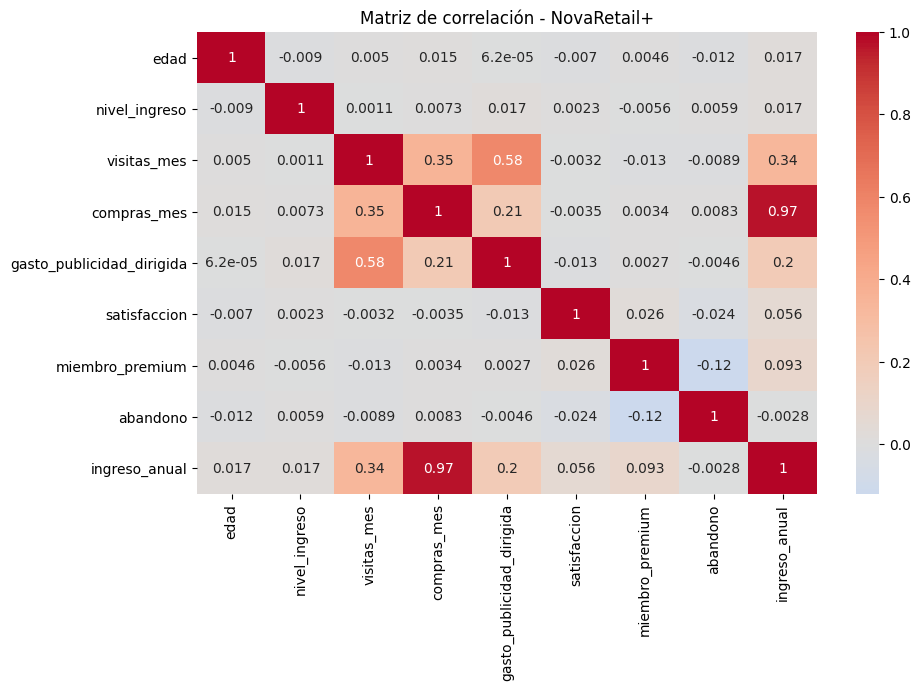

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación - NovaRetail+")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


---

🔍**Observaciones generales (Heatmap)**
-
- Se observa que la mayoría de las variables presentan **correlaciones muy bajas entre sí (valores cercanos a 0)**, lo que
  indica que las **variables del dataset son en gran parte independientes unas de otras**. Las excepciones más notorias
  son  `compras_mes` / `ingreso_anual` (r ≈ 0.97) y `visitas_mes / gasto_publicidad_dirigida` (r ≈ 0.58). Las
  únicas relaciones suficientemente fuertes como para merecer análisis adicional.
- La variable `abandono` no muestra correlación significativa con prácticamente ninguna otra variable, salvo una leve
  relación negativa con `miembro_premium` (r ≈ -0.12), lo cual sugiere que la retención no se explica fácilmente por las
  variables recogidas en este dataset de forma lineal.
- De igual forma, `satisfaccion` y `edad` **permanecen aisladas** del resto de las métricas de comportamiento y valor.


🔍**Observaciones respecto a `ingreso_anual`**
-
- Presenta **su correlación más fuerte y destacada con `compras_mes` (r ≈ 0.97)**, una relación casi perfecta que sugiere
  que el  número de **compras mensuales** es un predictor lineal muy robusto del ingreso anual —o viceversa— y que ambas
  variables podrían estar capturando el mismo constructo subyacente **(nivel de gasto / actividad del cliente)**.
- También muestra una **correlación moderada con `visitas_mes` (r ≈ 0.34)**, indicando que clientes con mayor frecuencia
  de visita tienden a generar más ingreso anual, aunque la relación es mucho más débil que con compras.
- El resto de variables **(`edad`, `nivel_ingreso`, `gasto_publicidad_dirigida`, `satisfaccion`, `miembro_premium` y
  `abandono`) presentan correlaciones muy cercanas a cero con ingreso_anual, lo que sugiere que esas dimensiones **no
  guardan una relación lineal relevante con el ingreso.**



---
**Scatterplot general**
-


---

El heatmap deja claro que la gran **mayoría de los pares de variables presentan correlaciones cercanas a cero**, por lo que **un scatterplot matrix completo aportaría muy poco** y sería difícil de interpretar.

Por eso se **generan scatterplots focalizados** únicamente en los pares con correlación relevante:
  1. compras_mes vs. ingreso_anual — para confirmar linealidad y detectar outliers.
  2. visitas_mes vs. gasto_publicidad_dirigida — para evaluar la forma de la relación y su dispersión.
  3. visitas_mes vs. ingreso_anual — para construir una visión más detallada del ingreso.


Dado que **el análisis descriptivo reveló que solo el 13.9% de los clientes pertenece al segmento premium**, pero este concentra **una proporción desproporcionada del ingreso anual**, `miembro_premium` se incorpora en los tres gráficos como **variable de segmentación visual** mediante hue encoding. Esto permite observar **si este segmento ocupa zonas diferenciadas en cada relación**, sin fragmentar el análisis ni alterar los coeficientes globales calculados en el heatmap.

---
**Scatterplot para pares clave**
-


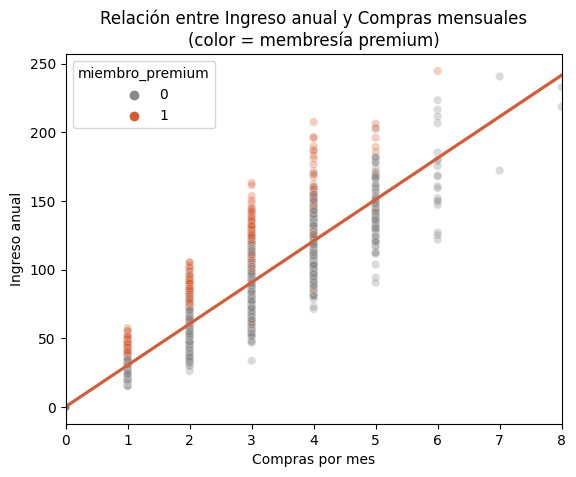

In [ ]:
sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual",
                hue="miembro_premium", alpha=0.3,
                palette={0: "#888888", 1: "#D85A30"})
sns.regplot(data=df, x="compras_mes", y="ingreso_anual",
            scatter=False, color="#D85A35")
plt.title("Relación entre Ingreso anual y Compras mensuales\n(color = membresía premium)")
plt.xlabel("Compras por mes")
plt.ylabel("Ingreso anual")
plt.show()

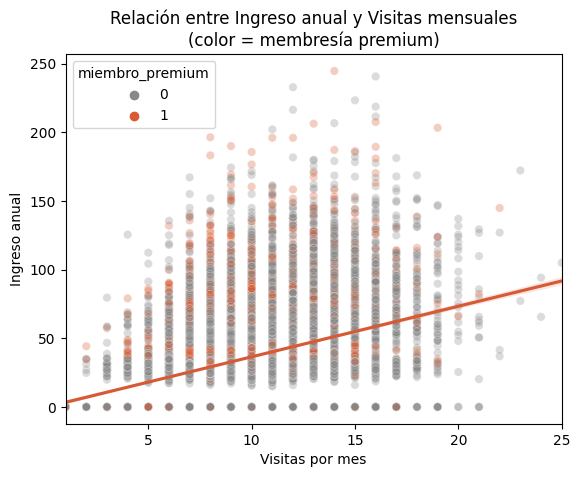

In [ ]:
sns.scatterplot(data=df, x="visitas_mes", y="ingreso_anual",
                hue="miembro_premium", alpha=0.3,
                palette={0: "#888888", 1: "#D85A30"})
sns.regplot(data=df, x="visitas_mes", y="ingreso_anual",
            scatter=False, color="#D85A35")
plt.title("Relación entre Ingreso anual y Visitas mensuales\n(color = membresía premium)")
plt.xlabel("Visitas por mes")
plt.ylabel("Ingreso anual")
plt.show()

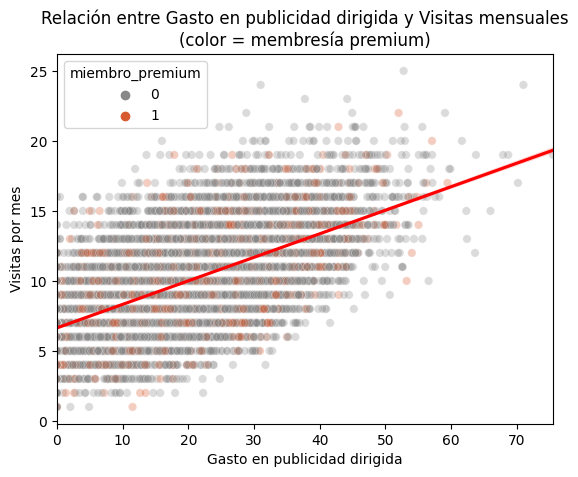

In [ ]:

sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes",
                hue="miembro_premium", alpha=0.3,
                palette={0: "#888888", 1: "#D85A30"})

sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes",
            scatter=False, color="red")
plt.title("Relación entre Gasto en publicidad dirigida y Visitas mensuales\n(color = membresía premium)")
plt.xlabel("Gasto en publicidad dirigida")
plt.ylabel("Visitas por mes")
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

---
🔍**Observaciones iniciales (Scatterplot)**
-
---
**`Ingreso anual` Vs. `compras_mes`**
  - **Dirección positiva:** a mayor número de compras mensuales, mayor ingreso anual, sin excepciones visibles.
  
  - **Dispersión media:** Los puntos se agrupan en columnas verticales discretas,  lo que revela que `compras_mes` es una
    ***variable discreta, no continua***. Dentro de cada columna hay variabilidad considerable en el ingreso, lo que
    explica que la dispersión no sea tan baja.
  
  - **Outliers:** se observan algunos puntos aislados en los extremos superiores (ingreso anual cercano a 250 con 5–7
    compras) y un punto notable con 7 compras pero ingreso alrededor de 170, por debajo de la tendencia esperada. No son
    casos extremos que distorsionen el análisis.
    
  - **Colinealidad:** la relación es ***casi perfectamente lineal.***  sto confirma la señal de alerta del heatmap:
   `compras_mes´ e `ingreso_anual` probablemente miden el mismo constructo subyacente y no deberían usarse juntas en un
    modelo predictivo.

   ***Variable adicional/`miembro_premium`:*** los puntos naranja no muestran una zona claramente diferenciada — aparecen
   distribuidos a lo largo de toda la línea de tendencia, **sugiriendo que la membresía premium no modifica
   sustancialmente la relación entre compras e ingreso anual**.

---
**`ingreso_anual` Vs. `visitas_mes`**

  - **Dirección positiva:** La línea de tendencia confirma que ***a mayor número de visitas, mayor ingreso anual**, pero
   la pendiente es **notablemente más suave** que en el scatterplot anterior.

  - **Dispersión alta:** Las columnas verticales son mucho más anchas que en `compras_mes`, con puntos que van desde
    ingreso 0 hasta 250 para un mismo número de visitas. Esto es  **completamente consistente con r ≈ 0.34,** la tendencia
    existe pero explica una fracción pequeña de la variabilidad del ingreso.

  - **Outliers:** se observan varios puntos con ingreso cercano a 0 distribuidos a lo largo de todo el rango de visitas,
   lo que representa usuarios que visitan frecuentemente pero **no generan ingreso** (navegación sin conversión). También
   hay puntos aislados en la zona superior (ingreso > 200) que superan ampliamente la tendencia esperada.

  - **Colinealidad:** no representa riesgo con `ingreso_anual`. Sin embargo, dado que
  `visitas_mes` se correlaciona también con `gasto_publicidad_dirigida`  podría generar colinealidad si ambas se usan
   juntas en un modelo.

***Variable adicional /`miembro_premium`:*** Los puntos naranja aparecen dispersos por toda la nube, sin concentrarse
  en una zona específica. Esto refuerza la observación del scatterplot anterior: **la membresía premium no segmenta
  visualmente** la relación entre visitas e ingreso, lo que sugiere que su impacto podría estar mediado por otras
  variables como `compras_mes`.

---
**`visitas_mes` Vs. `gasto_publicidad_dirigida`**

 - **Dirección positiva:** ***A mayor gasto en publicidad dirigida, mayor número de visitas mensuales***, con una
   pendiente visible y consistente con r ≈ 0.58.

 - **Dispersión media:** Los puntos forman filas horizontales discretas, lo que revela que `visitas_mes` también es una
   **variable discreta**. Dentro de cada fila hay variabilidad considerable en el gasto publicitario, pero la tendencia
   general es clara y la línea de regresión ajusta bien el centro de masa de los datos.

 - **Outliers:** Se observan **algunos puntos aislados en los extremos.** Usuarios con gasto publicitario alto (> 60) pero
   pocas visitas (< 5), y usuarios con visitas superiores a 20 en rangos bajos de gasto. **Ninguno parece suficientemente
   extremo** como para distorsionar el análisis, pero vale la pena **profundicar con un plot de coeficiente.**

 - **Colinealidad:** Dado que `visitas_mes` se correlaciona tanto con `gasto_publicidad_dirigida` (r ≈ 0.58) como con
   `ingreso_anual` (r ≈ 0.34), incluir ambas variables predictoras en un mismo modelo generaría colinealidad.

 ***Variable adicional /`miembro_premium`:*** Los puntos naranja aparecen distribuidos de forma homogénea a lo largo de
   toda la nube, sin concentrarse en zonas de alto gasto publicitario ni de alta frecuencia de visitas. Esto sugiere que
   **la empresa no segmenta su inversión publicitaria por membresía**, o que el impacto del gasto publicitario es similar
   entre premium y no premium.

---

---
**Coeficientes de correlación y evidencia numérica**
-


---
**Pearson / Spearman**
-
---

In [ ]:
# Correlación entre: ingreso anual y compras_mes

cols= df[['ingreso_anual', 'compras_mes']]
pearson = cols.corr(method='pearson')
pearson


,ingreso_anual,compras_mes
ingreso_anual,1.000000,0.967149
compras_mes,0.967149,1.000000


In [ ]:
# Correlación entre ingreso_anual y visitas_mes

cols= df[['ingreso_anual', 'visitas_mes']]
pearson= cols.corr(method='pearson')
pearson

,ingreso_anual,visitas_mes
ingreso_anual,1.000000,0.337147
visitas_mes,0.337147,1.000000


In [ ]:
# Correlación entre visitas_mes y gasto_publicidad_dirigida

cols= df[['visitas_mes', 'gasto_publicidad_dirigida']]
pearson= cols.corr(method='pearson')
pearson

,visitas_mes,gasto_publicidad_dirigida
visitas_mes,1.000000,0.578947
gasto_publicidad_dirigida,0.578947,1.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

---
🔍**Observaciones de correlación**
-
---
**`ingreso_anual` Vs `compras_mes`:**

 - **Dirección positiva:** Cuando el **ingreso anual aumenta, las compras por mes también tienden a aumentar.**
 - **Magnitud:** El coeficiente de Pearson es 0.967, lo que indica una **relación muy fuerte o casi perfecta entre ambas
   variables.
 - **Colinealidad:** Existe una alta colinealidad entre `ingreso_anual` y `compras_mes`, ya que el valor está muy cercano
   a 1. Esto sugiere que ambas variables comparten mucha información y **podrían generar redundancia.**

---    
**`ingreso_anual Vs. visitas_mes`:**

  - **Dirección positiva:** A medida que aumenta el **ingreso anual, también tienden a aumentar las visitas por mes**.
  -  **Magnitud:** El coeficiente de Pearson es 0.337, lo que indica **una relación débil a moderada.**
  - **Colinealidad baja:** con un valor  lejos de 1. Esto sugiere que `ingreso_anual` y `visitas_mes` aportan información
    relativamente distinta y **no presentan redundancia importante.**
---
**`visitas_mes` Vs. `gasto_publicidad_dirigida`:**

  - **Direcciónpositiva:** A **mayor gasto en publicidad dirigida, tienden a aumentar las visitas por mes**.
  - **Magnitud:** El coeficiente de Pearson es 0.579, lo que indica una relación moderada. Hay una asociación clara entre
    ambas variables, aunque no es extremadamente fuerte.
  - **Colinealidad moderada:** Las variables **comparten cierta información**, pero no al nivel de generar una redundancia
    crítica. Ambas **podrían coexistir sin mayores problemas**.
---

---
**Punto-biserial**
-
---

In [ ]:
# Correlación entre las variables ingreso anual y miembo premium

stats.pointbiserialr( df["ingreso_anual"], df["miembro_premium"] ),


(SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30),)

In [ ]:
# Correlación entre las variables ingreso anual y abandono
stats.pointbiserialr( df["ingreso_anual"], df["abandono"] )

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

In [ ]:
# Correlación entre las variables visitas mes y abandono
stats.pointbiserialr( df["visitas_mes"], df["abandono"] )

SignificanceResult(statistic=-0.008942702975011398, pvalue=0.273436216712885)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

---
🔍**Observaciones Punto-biserial**
-
**`ingreso_anual` Vs. `miembro_premium`**
  
   - **Relación direccion positiva baja:** Los ingesos mensuales de los clientes premium generan ligeramente más ingresos
     mas ingresos que los no suscritos, pero el impacto es pequeño.

   - **Magnitud extremadamente baja:** Un coeficiente de -0.0028 está tan cerca de 0 que no representa ninguna
     asociación real entre membresía premium e ingreso anual.

 ---
**`ingreso_anual` vs `abandono`**
   
   - **Dirección negativa:** Idéntico resultado al par anterior, lo que indica que el nivel de  ingreso anual tampoco
     explica si un cliente abandona o no la plataforma.

   - **Magnitud extremadamente baja:** — sin asociación práctica.

     
---
**`visitas_mes` vs `abandono`**
  
  - **Dirección negativa:** Los clientes que abandonan tienden marginalmente a tener menos visitas
    mensuales, aunque la diferencia es mínima.
  
  - **Magnitud extremadamente baja:** Ligeramente mayor que los dos anteriores, pero sigue sin representar una
    asociación relevante.

---

---
**V de Cramér**
-
---

In [ ]:
# Función para calcular V de Cramér

def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v

In [ ]:
# Aplicar V de Cramér en variables relevantes
cramer_v(df, "region", "tipo_dispositivo")

0.012378338407739397


---
**🔍Observaciones V de Cramér**
-
 - **Valor:** 0.0124
 - **Magnitud extremadamente baja** prácticamente cero.
 - **Interpretación:** No existe asociación relevante entre la región geográfica del cliente y el tipo de dispositivo que
   utiliza. La región no predice ni está relacionada con el dispositivo de acceso.
   
---

---
**Interpretación de resultados para el negocio**
-

---
✅**Hallazgo: Compras mensuales son el factor más fuertemente asociado con el ingreso anual**

1. **Evidencia visual** El scatterplot de `compras_mes` vs `ingreso_anual` muestra una relación lineal clara con
dispersión media, donde los puntos siguen de cerca la línea de tendencia a lo largo de todos los niveles de compra.

2. **Evidencia numérica** Correlación de Pearson r ≈ 0.97 (la más alta del dataset). La relación es
casi perfecta y estadísticamente significativa.

3. **Interpretación (no causal)** Los clientes con mayor número de compras mensuales están fuertemente asociados
con niveles más altos de ingreso anual. Ambas variables se mueven de forma casi paralela en el dataset.

4. **No podemos afirmar** Que aumentar el número de compras *cause* un mayor ingreso anual. La correlación
casi perfecta también sugiere que ambas variables podrían estar midiendo el mismo constructo subyacente — no son
necesariamente independientes entre sí.

5. **Implicación de negocio**La frecuencia de compra es el indicador más robusto del valor del cliente por lo que se
recomienda coordinar con los departamentos comercial y mercadeo  para desarrollar estrategias orientadas a aumentar la
recurrencia de compra como: programas de recompensa, recordatorios personalizados o incentivos de descuento en la
segunda compra tienen el mayor potencial de impacto en el ingreso anual.

---


✅ **Hallazgos adicionales:**
-

**Hallazgo 2: Las visitas mensuales tienen una asociación moderada con el ingreso anual**

1. **Evidencia visual** El scatterplot de `visitas_mes` vs `ingreso_anual` muestra una tendencia positiva con dispersión alta — usuarios con el mismo número de visitas presentan niveles de ingreso muy distintos, incluyendo clientes con visitas frecuentes pero ingreso cercano a cero.

2. **Evidencia numérica** Correlación de Pearson 0.34, moderada y estadísticamente presente, pero con baja capacidad explicativa individual.

3. **Interpretación (no causal)** Los clientes que visitan más la plataforma tienden a generar más ingreso anual,
aunque la relación está lejos de ser determinante. Existe un segmento relevante de usuarios que visita frecuentemente sin convertir en compra.

4. **No podemos afirmar** Que incrementar las visitas genere necesariamente mayor ingreso. La alta dispersión indica que visitar más no garantiza comprar más — hay otros factores no capturados en el dataset que median esa relación.

5. **Implicación de negocio** Las visitas son una condición necesaria pero no suficiente para generar ingreso. NovaRetail+ podría investigar qué diferencia a los visitantes frecuentes que compran de los que no lo hacen, y diseñar
estrategias de conversión específicas para ese segmento.

---

**Hallazgo 3: El gasto en publicidad dirigida está asociado con la frecuencia de visitas**

1. **Evidencia visual** El scatterplot de `gasto_publicidad_dirigida` vs `visitas_mes` muestra una tendencia positiva con
dispersión media. Los puntos naranja (premium) aparecen distribuidos homogéneamente, sin concentrarse en zonas de alto
gasto.

2. **Evidencia numérica** Correlación de Pearson 0.58 moderada-alta, la segunda más fuerte del dataset después del par
`compras_mes` / `ingreso_anual`.

3. **Interpretación (no causal)** Un mayor gasto en publicidad dirigida está asociado con una mayor frecuencia de visitas
mensuales. Esto es consistente con la cadena causal hipotética: publicidad → visitas → compras → ingreso anual.

4. **No podemos afirmar** Que el gasto publicitario *cause* las visitas, ni que optimizar el gasto publicitario impacte
directamente el ingreso. La cadena causal es una hipótesis que requeriría un diseño experimental para ser validada.

5. **Implicación de negocio** La inversión en publicidad dirigida parece estar cumpliendo su función de atraer tráfico a
la plataforma. Sin embargo, dado que las visitas solo explican parcialmente el ingreso, NovaRetail+ podría evaluar si
el gasto publicitario se está traduciendo en conversiones reales o únicamente en tráfico sin compra.

---

**Hallazgo 4: La membresía premium y el abandono no están asociados linealmente con el ingreso anual**

1. **Evidencia visual** En los tres scatterplots, los puntos naranja (premium) aparecen distribuidos homogéneamente sin
 ocupar zonas diferenciadas de alto ingreso.

2. **Evidencia numérica** Coeficiente punto-biserial: `ingreso_anual` vs `miembro_premium` = -0.0028 (p = 0.729); `ingreso_anual` vs `abandono` = -0.0028 (p = 0.729); `visitas_mes` vs `abandono` = -0.0089 (p = 0.273). Ninguno es estadísticamente significativo.

3. **Interpretación (no causal)** La membresía premium y el comportamiento de abandono no se asocian de forma
lineal con el ingreso anual ni con la frecuencia de visitas en este dataset.

4. **No podemos afirmar** Que ser cliente premium no tenga valor para el negocio. La ausencia de correlación lineal no descarta relaciones no lineales, ni el impacto de la  membresía en otras dimensiones como satisfacción o retención a largo plazo.

5. **Implicación de negocio**El modelo de membresía premium de NovaRetail+ no está diferenciando a los clientes por ingreso generado. Esto podría indicar que los beneficios premium no están alineados con los comportamientos que realmente impulsan el ingreso, o que la segmentación actual necesita ser revisada.

---

**Hallazgo 5: La región geográfica y el tipo de dispositivo son variables independientes**

1. **Evidencia visual** No aplica — este hallazgo proviene exclusivamente del análisis de asociación
entre variables categóricas.

2. **Evidencia numérica** V de Cramér = 0.0124 — prácticamente cero, sin asociación relevante entre región y tipo de dispositivo.

3. **Interpretación (no causal)** La región geográfica del cliente no está asociada con el tipo de dispositivo
que utiliza para acceder a la plataforma. El comportamiento de acceso es homogéneo entre regiones.

4. **No podemos afirmar** Que esta independencia se mantenga en otras variables categóricas del dataset,
ni que no existan patrones regionales en dimensiones no analizadas en este proyecto.

5. **Implicación de negocio** NovaRetail+ no necesita desarrollar estrategias diferenciadas por dispositivo
según región. Las decisiones de optimización de experiencia de usuario (UX móvil vs escritorio) pueden aplicarse de forma uniforme sin segmentación geográfica.





---
**Limitaciones y próximos pasos**
-
---


**Limitaciones:**
-
- **Correlación ≠ causalidad:** Ninguno de los hallazgos permite afirmar que una variable provoca cambios en otra. Las
  asociaciones encontradas describen patrones, no mecanismos.
  
- **Variables discretas:** Tanto `compras_mes` como `visitas_mes` son discretas, lo que limita la precisión de los
  coeficientes de correlación y genera agrupamientos artificiales en los scatterplots.

- **Colinealidad no resuelta:** `compras_mes` e `ingreso_anual` presentan r ≈ 0.97, lo que sugiere que podrían estar
  midiendo el mismo constructo. Usar ambas en un modelo predictivo produciría resultados poco confiables.

- **Membresía premium subrepresentada** — solo el 13.9% de los clientes son premium, lo que limita el poder estadístico
  para detectar diferencias significativas entre segmentos.

- **Variables no capturadas** — factores como ticket promedio por compra, canal de adquisición, o historial de
  interacciones no están en el dataset y podrían explicar mejor la variabilidad del ingreso anual.

---

**Próximos pasos:**
-
1. **Probar segmentación adicional** Analizar si la relación entre `compras_mes` e `ingreso_anual` varía según región o tipo de dispositivo mediante análisis de subgrupos.Explorar si existe un umbral de visitas mensuales a partir del cual la probabilidad de compra aumenta significativamente.

2. **Investigar el segmento premium:** Comparar el ticket promedio por compra entre clientes premium y no premium para determinar si el valor diferencial está en la frecuencia o en el monto.

3. **Evaluar el retorno de la inversión publicitaria:**
   - Calcular el ratio `ingreso_anual` /`gasto_publicidad_dirigida` por cliente para identificar si la inversión publicitaria está generando retorno real o únicamente tráfico sin conversión.

   - Segmentar los clientes x gasto publicitario y comparar sus tasas de conversión (visitas que resultan en compra) para detectar si existe un umbral de inversión óptimo.
  
   - Cruzar `gasto_publicidad_dirigida` con `abandono` para determinar si los clientes que abandonan la plataforma recibieron niveles de inversión publicitaria similares a los que permanecen — lo que indicaría que el problema no es de adquisición sino de retención.

---

## Contacto
[![LinkedIn](https://img.shields.io/badge/LinkedIn-0A66C2?style=flat&logo=linkedin&logoColor=white)](https://linkedin.com/in/tu-usuario)
[![Email](https://img.shields.io/badge/Email-D14836?style=flat&logo=gmail&logoColor=white)](mailto:tu@email.com)